### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [ ]:
data = pd.read_csv('data/coupons.csv')

In [ ]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

2. Investigate the dataset for missing or problematic data.

In [ ]:
print('Which column has NULL \n',data.isnull().sum())
# print(data.info())
# data.shape
# data.dtypes
# data.toCoupon_GEQ15min.unique()


Which column has NULL 
 destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64


3. Decide what to do about your missing data -- drop, replace, other...

**Car column=> This does not affect analysis hence can be ignored/dropped **

Other NULL columns(with low volume of NULLs) can be filled with mean/median of the data distribution pattern of those columns.
Will consider this as next assignment and do a comparison to see if filling out  NULL improve data quality/outcome

In [ ]:
# data.car.unique() # Out of 12684, car column has  12576 nulls. THis does not affect current analysis hence ignore/drop this column

# check unique values for important columns

print(data.coupon.unique())
# print(data.destination.unique())
# print(data.expiration.unique())
# print(data.temperature.unique())
# print(data.time.unique())
# print(data.weather.unique())
# print(data.passanger.unique())
# print(data.Bar.unique())

['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']


4. What proportion of the total observations chose to accept the coupon?



In [ ]:
proportion_accepted = data['Y'].mean()
print(f"Percentage that accepted the coupon: {proportion_accepted:.2%}")

Percentage that accepted the coupon: 56.84%


5. Use a bar plot to visualize the `coupon` column.

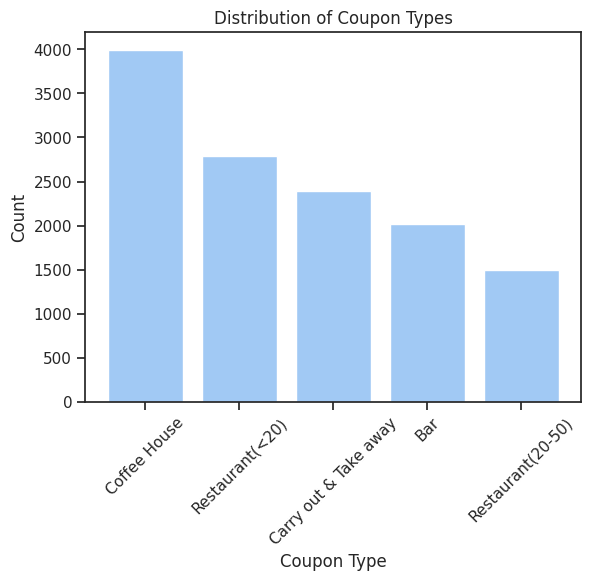

In [ ]:
# sns.countplot(x='coupon', data=data)
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.title('Distribution of Coupon Types')
plt.bar(data['coupon'].value_counts().index, data['coupon'].value_counts().values)
plt.xticks(rotation=45)
plt.show()

6. Use a histogram to visualize the temperature column.

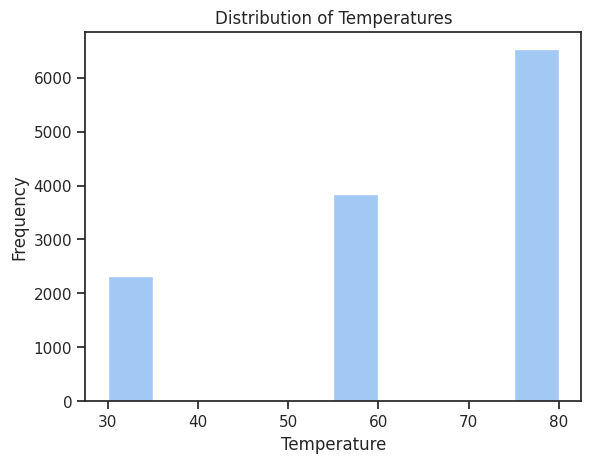

In [ ]:
plt.hist(data['temperature'])
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Distribution of Temperatures')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [ ]:
# data.coupon.unique()
bar_coupons = data.query('coupon == "Bar"')
print(bar_coupons.head())

        destination  passanger weather  temperature  time coupon expiration  \
9   No Urgent Place     Kid(s)   Sunny           80  10AM    Bar         1d   
13             Home      Alone   Sunny           55   6PM    Bar         1d   
17             Work      Alone   Sunny           55   7AM    Bar         1d   
24  No Urgent Place  Friend(s)   Sunny           80  10AM    Bar         1d   
35             Home      Alone   Sunny           55   6PM    Bar         1d   

    gender age      maritalStatus  ...  CoffeeHouse CarryAway  \
9   Female  21  Unmarried partner  ...        never       NaN   
13  Female  21  Unmarried partner  ...        never       NaN   
17  Female  21  Unmarried partner  ...        never       NaN   
24    Male  21             Single  ...        less1       4~8   
35    Male  21             Single  ...        less1       4~8   

   RestaurantLessThan20 Restaurant20To50 toCoupon_GEQ5min toCoupon_GEQ15min  \
9                   4~8              1~3               

2. What proportion of bar coupons were accepted?


In [ ]:
# Calculate the proportion of accepted bar coupons
portion_bar_acccepsted = data.query('coupon == "Bar" & Y == 1')
fraction_of_tot_bar =  portion_bar_acccepsted.shape[0]/ data.query('coupon == "Bar"').shape[0]
print(f"Interms of percentage of bar coupons accepted: {fraction_of_tot_bar:.2%}")

Interms of percentage of bar coupons accepted: 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


**NOTE : Didn't consider who NEVER visited  to BAR for this calculation**

In [ ]:
print(data.Bar.unique())

portion_bar_acccepsted = data.query('coupon == "Bar" & Y == 1')
fraction_of_tot_bar =  portion_bar_acccepsted.shape[0]
data[(data['Bar'] == '1~3') | (data['Bar'] == 'less1') ]['Bar'].unique() # check correct dataset retrieved. Didn't consider who never visited  to BAR for this calculation
fewer_or3_in_a_month = data[(data['Bar'] == '1~3') | (data['Bar'] == 'less1') ].shape[0] # check correct dataset retrieved. Didn't consider who never visited  to BAR for this calculation

data[(data['Bar'] == '4~8') | (data['Bar'] == 'gt8') ]['Bar'].unique()
four_or_more_in_a_month = data[(data['Bar'] == '4~8') | (data['Bar'] == 'gt8') ].shape[0]

print(f"Acceptance rate of bar coupons by 3 or less in month BAR GOERS: {fraction_of_tot_bar/fewer_or3_in_a_month :.2%}")
print(f"Acceptance rate of bar coupons by more than 3 times in month BAR GOERS: {fraction_of_tot_bar/four_or_more_in_a_month :.2%}")


['never' 'less1' '1~3' 'gt8' nan '4~8']
Acceptance rate of bar coupons by 3 or less in month BAR GOERS: 13.89%
Acceptance rate of bar coupons by more than 3 times in month BAR GOERS: 58.04%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


Answer is included in my code output.
**Drivers who go to a bar more than once a month and are over 25 have a higher acceptance rate.**

In [ ]:
# print('BAR data ',data.Bar.unique())
# print('age data ',data.age.unique())

bar_frequent_age_25_plus = data[(data['Bar'].isin(['1~3', '4~8', 'gt8'])) & (data['age'].isin(['26', '31', '36', '41', '46', '50plus']))]
acceptance_rate_group1 = bar_frequent_age_25_plus['Y'].mean()

other_drivers = data[~((data['Bar'].isin(['1~3', '4~8', 'gt8'])) & (data['age'].isin(['26', '31', '36', '41', '46', '50plus'])))]
acceptance_rate_group2 = other_drivers['Y'].mean()

print(f"Acceptance rate for drivers who go to a bar more than once a month and are over 25: {acceptance_rate_group1:.2%}")
print(f"Acceptance rate for all other drivers: {acceptance_rate_group2:.2%}")

if acceptance_rate_group1 > acceptance_rate_group2:
    print("Drivers who go to a bar more than once a month and are over 25 have a higher acceptance rate.")
elif acceptance_rate_group1 < acceptance_rate_group2:
    print("Other drivers have a higher acceptance rate.")
else:
    print("There is no significant difference in acceptance rates between the two groups.")

Acceptance rate for drivers who go to a bar more than once a month and are over 25: 62.15%
Acceptance rate for all other drivers: 55.35%
Drivers who go to a bar more than once a month and are over 25 have a higher acceptance rate.


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


**A visual representation is included for better understanding**

Acceptance rate: More frequent bar visitors not travelling with kid & not in occupations farming, fishing, or forestry : 62.31%
Acceptance rate for all other drivers: 54.60%


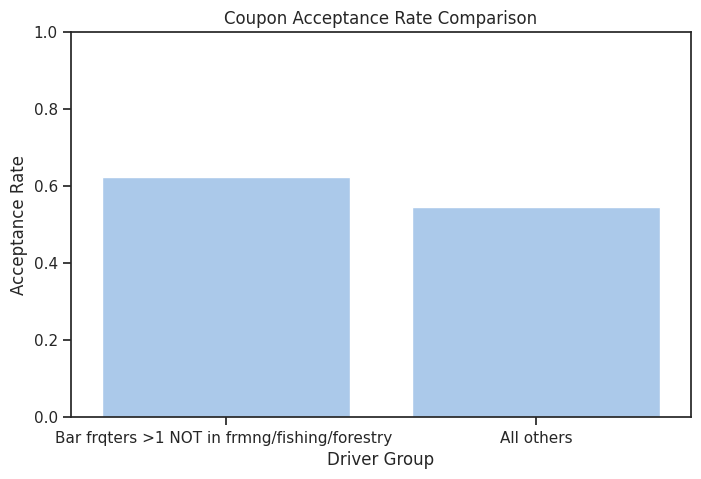

In [ ]:
# Validate data
# print(data.passanger.unique())
# print(data.occupation.unique())

# display_filter = data[ data['Bar'].isin(['1~3', '4~8', 'gt8']) &
    #  data['passanger'].isin(['Alone','Friend(s)','Partner']) &
    #  (~data['occupation'].isin(['Farming Fishing & Forestry']))
    #  ][['Bar','occupation','passanger']].value_counts()
# print(display_filter)


filter_cond = (data['Bar'].isin(['1~3', '4~8', 'gt8']) &
     data['passanger'].isin(['Alone','Friend(s)','Partner']) &
     (~data['occupation'].isin(['Farming Fishing & Forestry']))
    )

more_than_1_notfarming_no_kid_passanger = data[filter_cond]
acceptance_rate_group1 = more_than_1_notfarming_no_kid_passanger['Y'].mean()

other_group = data[~filter_cond]
acceptance_rate_group2 = other_group['Y'].mean()

print(f"Acceptance rate: More frequent bar visitors not travelling with kid & not in occupations farming, fishing, or forestry \
: {acceptance_rate_group1:.2%}")
print(f"Acceptance rate for all other drivers: {acceptance_rate_group2:.2%}")


# Outcome Visualization
acceptance_rates_data = pd.DataFrame({
    'Driver Group': ['Bar frqters >1 NOT in frmng/fishing/forestry ', 'All others'],
    'Acceptance Rate': [acceptance_rate_group1, acceptance_rate_group2]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Driver Group', y='Acceptance Rate', data=acceptance_rates_data)
plt.title('Coupon Acceptance Rate Comparison')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for percentage
plt.show()




6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



**A visual representation is included for better understanding**

(0.0, 1.0)

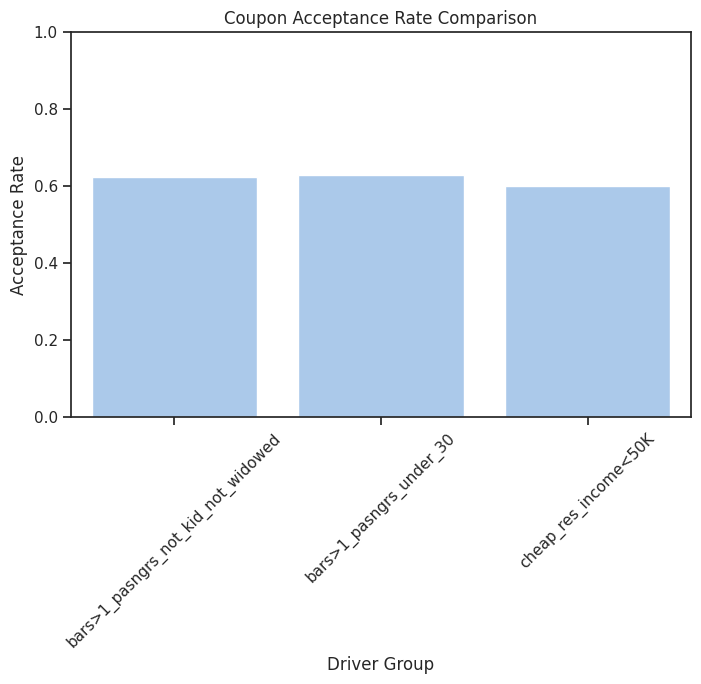

In [ ]:
# Data PREVIEW for applying correct filter
# print(data['Bar'].unique())
# print(data['passanger'].unique())
# print(data['maritalStatus'].unique())
# print(data['age'].unique())
# print('coffee house ',data['CoffeeHouse'].unique())
# print('RestaurantLessThan20 ', data['RestaurantLessThan20'].unique())
# print('Restaurant20To50 ',data['Restaurant20To50'].unique())
# print('CarryAway ', data['CarryAway'].unique())
# print(data['income'].unique())

condition1 = (data['Bar'].isin(['1~3', '4~8', 'gt8','4~8']) &
              data['passanger'].isin(['Alone','Friend(s)','Partner']) &
               (~data['maritalStatus'].isin(['Widowed']))
             )
condition2 = (data['Bar'].isin(['1~3', '4~8', 'gt8','4~8']) &
              data['age'].isin(['21', '26','below21'])
             )
condition3 = (data['RestaurantLessThan20'].isin(['4~8', 'gt8']) &
              (~data['income'].isin(['$62500 - $74999','$75000 - $87499','$50000 - $62499'
              ,'$100000 or More','$87500 - $99999']))
)

acceptance_rate_group1 = data[condition1]['Y'].mean()
acceptance_rate_group2 = data[condition2]['Y'].mean()
acceptance_rate_group3 = data[condition3]['Y'].mean()

# DATA VISUALIZATION

graph_data = pd.DataFrame({
    'Driver Group': ['bars>1_pasngrs_not_kid_not_widowed', 'bars>1_pasngrs_under_30'
    ,'cheap_res_income<50K'],
    'Acceptance Rate': [acceptance_rate_group1, acceptance_rate_group2,acceptance_rate_group3]
})
plt.figure(figsize=(8, 5))
sns.barplot(x='Driver Group', y='Acceptance Rate', data=graph_data)
plt.title('Coupon Acceptance Rate Comparison')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=45)
plt.ylim(0, 1)



7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?


***Analysis result:***

1. Current Amazon data coupon data was collected mostly during summer season
2. Out of 12684 records, car column has  12576 nulls. This does not affect analysis hence can be ignored/dropped
3. Travellers prefer Coffee house coupons most followed by Restaurants < 20$
4. Bar coupons were mostly used by the travellers who visits more than 3 times a month
5. farming, fishing, or forestry travellers utilised more Bar coupons
6. during travel, Lower Salary or paying less for restaurant has very minimal effect on drinking habit. Travellers of all 3 categories utilised Bar coupons almost equally


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

# **Summary of my independent analysis is at the end of the notebook**

***Analyze if temparature has any effect on type of coupon acceptance***

<Axes: title={'center': 'Coupon acceptance Vs Ambient Temperature Effect'}, xlabel='temperature', ylabel='count'>

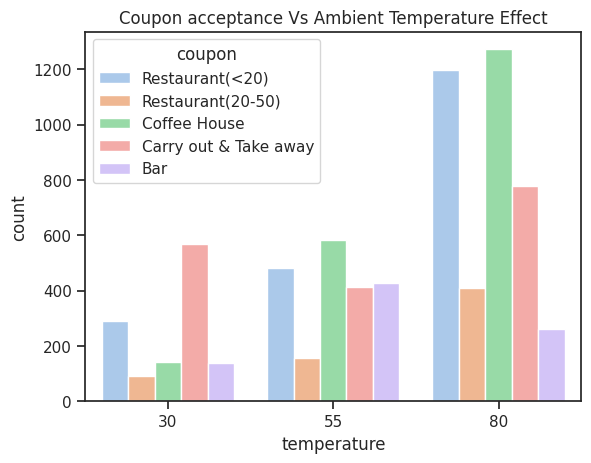

In [ ]:
# Filtering for accepted coupons (Y=1) and counting occurrences of each coupon/temperature pair
# to identify how teamperature affetcs people's coupon acceptance pattern
# It shows travelers prefer to visit reataurants under $20 or coffee house during hot seasons

accepted_counts = data[data['Y'] == 1][['coupon', 'temperature']].value_counts().reset_index(name='count').sort_values(by=['temperature','coupon'], ascending=False)
plt.title('Coupon acceptance Vs Ambient Temperature Effect')
# Plotting the bar chart
sns.barplot(x='temperature', y='count', hue='coupon', data=accepted_counts)
# Plotting the histogram


# Analyze which coupons travelers accepted even though it was in a opposite direction the individul was travelling

<Axes: title={'center': 'Coupon acceptance Vs Travel Direction(opposite)'}, xlabel='direction_opp', ylabel='count'>

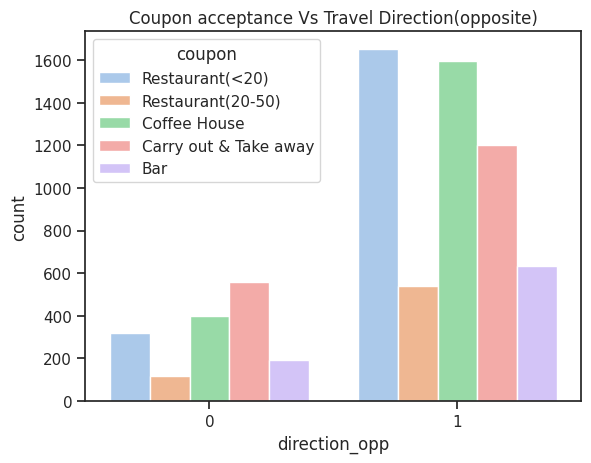

In [ ]:
data.direction_opp.unique()
# data['Y'].direction_opp.value_counts()
# plt.figure(figsize=(20,5))
# plt.subplot(121)
plt.title('Coupon acceptance Vs Travel Direction(opposite)')
opposite_direction_acccpet = data[data['Y'] == 1][['direction_opp','coupon']].value_counts().reset_index(name='count').sort_values(by=['direction_opp','coupon'], ascending=False)
sns.barplot(x='direction_opp', y='count', hue='coupon', data=opposite_direction_acccpet)



**Analyze how coupon expiration affetcs coupon acceptance**

<Axes: title={'center': 'Coupon acceptance Vs Expiration'}, xlabel='expiration', ylabel='count'>

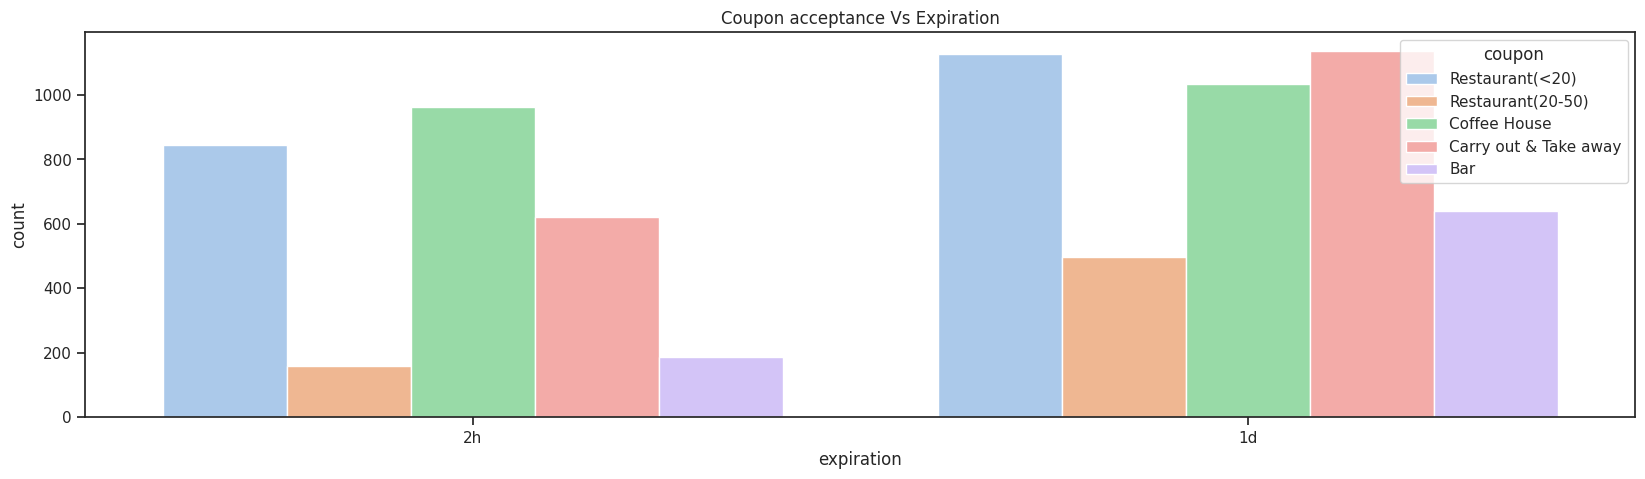

In [ ]:
# data.info()
# data['expiration'].unique()
expiration_coupon = data[data['Y'] == 1][['expiration','coupon']].value_counts().reset_index(name='count').sort_values(by=['expiration','coupon'], ascending=False)
# print(expiration_coupon)
plt.figure(figsize=(20,5))
plt.title('Coupon acceptance Vs Expiration')
sns.barplot(x='expiration', y='count', hue='coupon', data=expiration_coupon)



**Analyze has destination any impact on coupon rejection ?**

**Outcome: Coupon Rejection is higer amongst travellers who are NOT heading towards office or home**

<Axes: title={'center': 'Coupon rejection  Vs Destination'}, xlabel='destination', ylabel='count'>

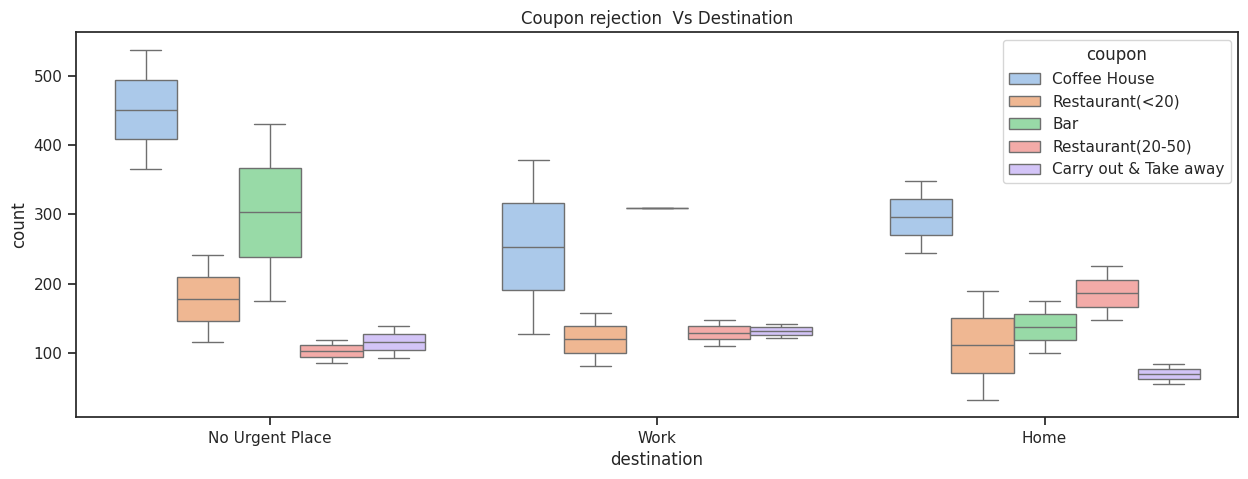

In [ ]:
# data.info()
# expiration_coupon_not_accepted = data[data['Y'] == 0][['expiration','coupon','toCoupon_GEQ5min','toCoupon_GEQ15min','toCoupon_GEQ25min']].value_counts()
expiration_coupon_not_accepted = data[data['Y'] == 0][['expiration','coupon','destination']].value_counts().reset_index(name='count').sort_values(by=['expiration','count'], ascending=False)
# print(expiration_coupon_not_accepted)
plt.figure(figsize=(15,5))
plt.title('Coupon rejection  Vs Destination')
sns.boxplot(x='destination', y='count', hue='coupon', data=expiration_coupon_not_accepted)


**My Own Analysis**

Summary :

 1. During summer time coupon acceptance rate is higher

 2. Travellers even preferred to travel opposite direction for coffee house/ less costly restaurants

 3. Less that 20$ Restaurant, coffee house & carry out coupons having  1 day validity were widely accepted

 4. Less than20$ Restaurant &  coffee house coupons having  2hrs  validity were widely accepted

 5. Drivers went in opposite direction to avail their favourite food court to use their coupons

 6. Coupon Rejection is higer amongst travellers who are NOT heading towards office or home